# AI lab Practical 5 - Image Sementation

## **Introduction**
In this section, we will explore the fundamental concepts in order to capture the object shape by applying several techniques, including Thresholds, k-Mean, Mean Shift and Graph Cut for segmentation. For the practical component, you are provided with a blurred image file, “`birds.png`”, located in the “`test_image`” folder. The objective of this laboratory exercise is to enhance the given image so that it appears clearer and visually improved.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
img_0 = cv2.imread(r"/Users/somchannreaksmey/Documents/I4-AMS-B/Artificial-Intelligence/TP5/bird.png")
img_0 = cv2.cvtColor(img_0, cv2.COLOR_BGR2RGB)
img = cv2.cvtColor(img_0, cv2.COLOR_BGR2GRAY)

## 1. Binary Image Segmentation

Defined the intensithy function by $f(x,y)$ and the thresholds is $T$, the binary image is convert the intensity of $f(x, y)$ into value $[0,1]$ by:
$$g(x, y)= \left\{ \begin{array}{l}
0 &if &f(x,y)\geq T \\\\
1 &if &f(x,y)< T
\end{array}\right.$$

Task: Applied this k-mean technique on “`birds.png`” image and display your result.

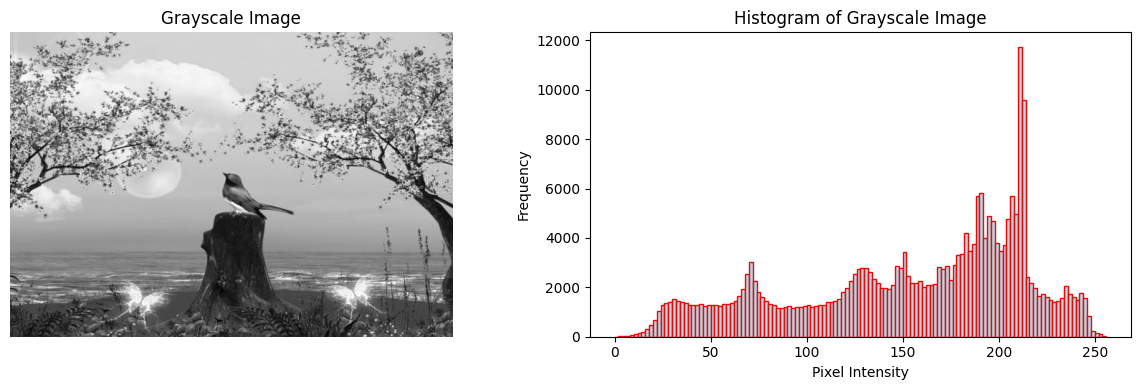

In [21]:
# Display grayscale image and its histogram
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.title("Grayscale Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Histogram of Grayscale Image")
plt.hist(img.ravel(), bins=128, range=[0, 256], color='lightblue', edgecolor='red')
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

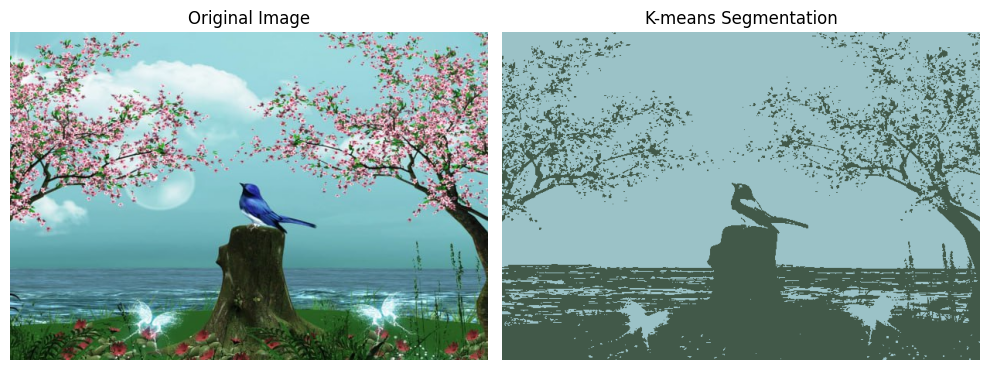

In [4]:
# Apply k-means clustering for segmentation
k = 2
pixel_values = img_0.reshape((-1, 3)).astype(np.float32)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
segmented_img = centers[labels.flatten()].reshape(img_0.shape)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_0)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("K-means Segmentation")
plt.imshow(segmented_img)
plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Segmentation as K-mean Clustering

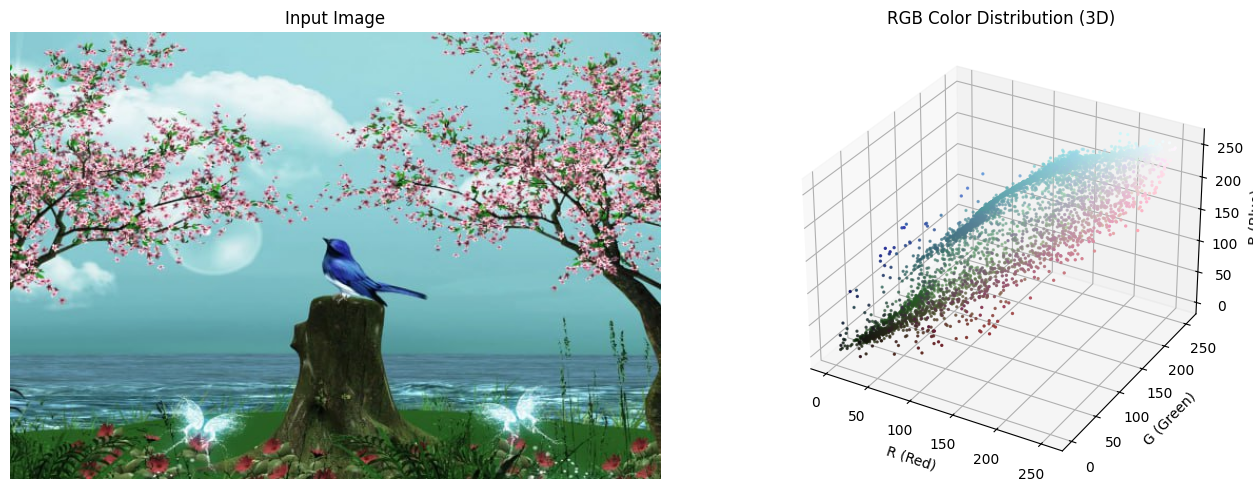

In [27]:
# Display input image and 3D RGB distribution side by side
sample = pixel_values[::50]
fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.imshow(img_0)
ax1.set_title("Input Image")
ax1.axis("off")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(sample[:, 0], sample[:, 1], sample[:, 2], c=sample / 255.0, s=2)
ax2.set_xlabel("R (Red)")
ax2.set_ylabel("G (Green)")
ax2.set_zlabel("B (Blue)")
ax2.set_title("RGB Color Distribution (3D)")
plt.tight_layout()
plt.show()

Task: Applied this k-mean technique on “birds.png” image and display your result.

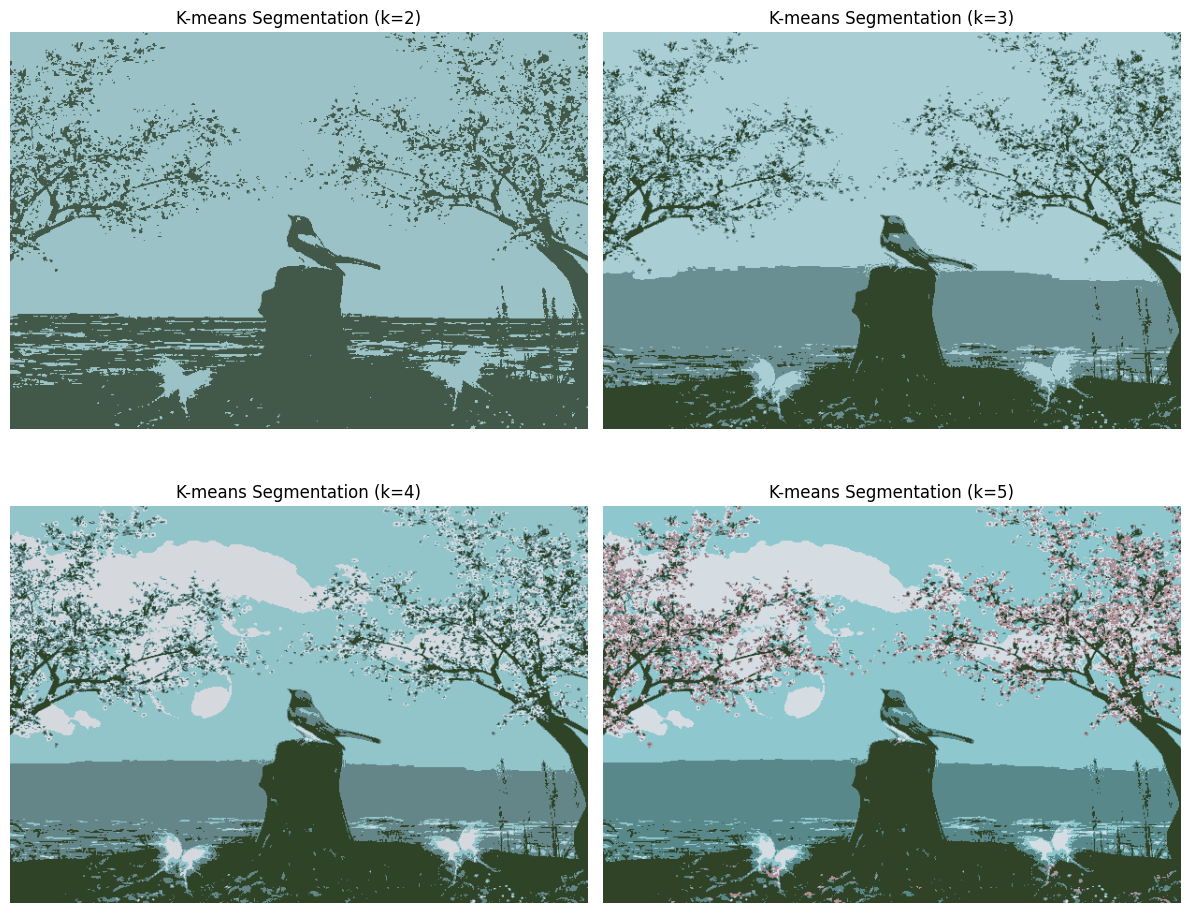

In [28]:
# Apply k-means clustering with different k values
k_values = [2, 3, 4, 5]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

for i, k_val in enumerate(k_values):
    _, labels_k, centers_k = cv2.kmeans(pixel_values, k_val, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers_k = np.uint8(centers_k)
    segmented_k = centers_k[labels_k.flatten()].reshape(img_0.shape)
    
    axes[i].imshow(segmented_k)
    axes[i].set_title(f"K-means Segmentation (k={k_val})")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## 3. Graph Base Segmentation
Let $i$ and $j$ be two pixels whose the values of intensity are $f_i$ and $f_j$.

**Pixel Dissimilarity:**
$$d(f_i,f_j)=\sqrt{\sum_k(f_i-f_j)^2}$$

**Pixel Affinity:**
$$w(f_i, f_j)=A(f_i, f_j)=\exp(-\frac{1}{2\sigma^2}d(f_i, f_j))$$

Note smaller the **dissimilarity** then it the larger the **affinity**. The objectvie we aim to cut the sub-graph in order to seperated the region of the object.

**Graph Cut:**
**Cut** $C=(V_A, V_B)$ is a partition of vertices $V$ of a graph $G=(V, E)$ into two disjoint subsets $V_A$ and $V_B$.
**Cut-Set:** Set of edges whoes vertices are in different subsets of partition.
**Cost of Cut:** Sum of weights of cut-sets edges.
$$cut(V_A, V_B)= \sum_{u\in V_A, v\in V_B} w(u,v)$$
Objective is $Min(cut(V_A,V_B))$

Task: Applied this technique on “`birds.png`” image and display your result.

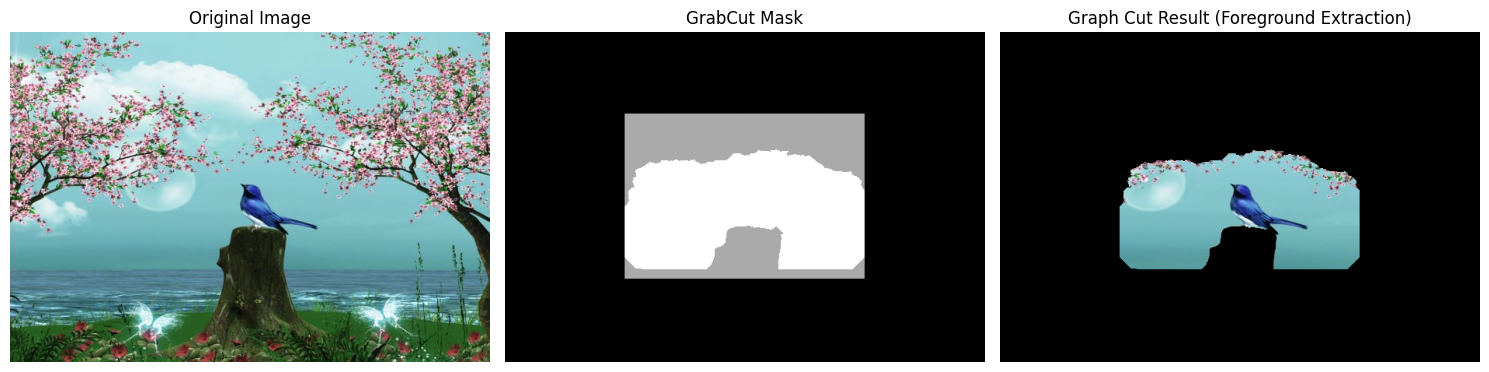

In [34]:
# Apply GrabCut algorithm (graph cut based method)
mask = np.zeros(img_0.shape[:2], np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

# Define a rectangle around the object (approximate foreground region)
height, width = img_0.shape[:2]
rect = (width//4, height//4, width//2, height//2)

# Apply GrabCut algorithm
cv2.grabCut(img_0, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

# Create binary mask where sure foreground and probably foreground are marked
mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype('uint8')
grabcut_result = img_0 * mask2[:, :, np.newaxis]

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_0)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap='gray')
axes[1].set_title("GrabCut Mask")
axes[1].axis("off")

axes[2].imshow(grabcut_result)
axes[2].set_title("Graph Cut Result (Foreground Extraction)")
axes[2].axis("off")

plt.tight_layout()
plt.show()